# The combined famb book on one portfolio engine — fade + carry

Both surviving sleeves under ONE `QueryDrivenBacktest`: the
pre-registered STRG75 richness fade (episodic, tag `famb_fade`) and the
always-on short FLY25 carry (tag `famb_fly`), sharing a TimeGrid, a
portfolio, and the engine's MTM. Gates are tag-scoped so the sleeves
never jam each other. Extending the TimeGrid forward runs this book as
the pre-registered forward test with production marks.

The first section answers the practical question directly: what was the
most recent actual trade in each sleeve — instruments, strikes, prices.

In [1]:
CONFIG = dict(contracts_fade=1.0, contracts_fly=1.0, tcost_vol_bp=0.125)
CONFIG

{'contracts_fade': 1.0, 'contracts_fly': 1.0, 'tcost_vol_bp': 0.125}

In [2]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_fade_qdb import (PRE_REGISTERED, build_signal_panel,
                           closed_positions_frame)
from famb_fly_qdb import build_roll_schedule
from famb_combined_qdb import make_combined_backtest, split_by_sleeve
from famb_common import intra_quarter_backtest, n_contracts
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from RVUtils.SFRRVLab.stats import nw_tstat

panel, fade_holdings = build_signal_panel(return_holdings=True)
schedule, fly_sessions, fly_holdings = build_roll_schedule(
    return_holdings=True)
print(f"fade panel {len(panel)} sessions; fly schedule {len(schedule)} "
      f"holdings; sample -> {panel['as_of'].max().date()}")

fade panel 1052 sessions; fly schedule 18 holdings; sample -> 2026-07-28


## The most recent trade in each sleeve — the RV trade, concretely

In [3]:
tr = intra_quarter_backtest(
    fade_holdings, thr_bp=PRE_REGISTERED["thr_bp"],
    exit_frac=PRE_REGISTERED["exit_frac"],
    max_hold=PRE_REGISTERED["max_hold"], direction="fade",
    cost_mult=1.0, n_legs=n_contracts("STRG75"))
last = sorted(tr, key=lambda t: t["entry"])[-1]
row = panel[panel["as_of"] == last["entry"]].iloc[0]
h = next(h for h in fade_holdings
         if h.marks.index[0] <= last["entry"] <= h.marks.index[-1])
print("=== FADE sleeve — most recent completed trade ===")
print(f"  instruments: SELL 1 x {row['put_label']}  +  "
      f"SELL 1 x {row['call_label']}   (the +/-75bp strangle on "
      f"{row['symbol']})")
print(f"  signal:      listed strangle premium was "
      f"{last['entry_rich']:+.2f}bp RICH vs the ZQ-lattice fair value "
      f"(threshold {PRE_REGISTERED['thr_bp']}bp)")
print(f"  entry {last['entry'].date()} at "
      f"{float(h.marks.loc[last['entry']]):.2f}bp premium;  exit "
      f"{last['exit'].date()} at {float(h.marks.loc[last['exit']]):.2f}bp "
      f"({last['sessions']} sessions, exit at "
      f"{PRE_REGISTERED['exit_frac']:.0%} of entry richness or the clock)")
print(f"  P&L: {last['gross_bp']:+.2f}bp gross, {last['net_bp']:+.2f}bp "
      f"net @1x  (${last['net_bp'] * 25:+,.0f} per 1-lot)")

completed = [h for h in fly_holdings
             if h.marks.index[-1] < panel["as_of"].max()]
hc = completed[-1]                      # most recent holding that ROLLED
ks = sorted(k for _, k, _ in hc.legs)
print("\n=== CARRY sleeve — most recent completed holding ===")
print(f"  instruments: SELL the {hc.symbol} {ks[0]:.2f}/{ks[1]:.2f}/"
      f"{ks[2]:.2f} call butterfly (1/-2/1), struck at the ZQ-tree modal "
      "strike, held to the roll")
print(f"  entry {hc.marks.index[0].date()} at "
      f"{float(hc.marks.iloc[0]):.2f}bp (long-fly premium; we are short); "
      f"roll {hc.marks.index[-1].date()} at "
      f"{float(hc.marks.iloc[-1]):.2f}bp")
gross = -(float(hc.marks.iloc[-1]) - float(hc.marks.iloc[0]))
print(f"  P&L: {gross:+.2f}bp gross - 1.0bp roll costs "
      f"(${(gross - 1.0) * 25:+,.0f} per 1-lot)")
print("\nThe RV in one line: the option market prices MORE probability "
      "mass away from the ZQ lattice's modal path than the lattice "
      "carries; the fade sells that surplus when it spikes and buys it "
      "back on convergence, the carry sells the modal bucket's structure "
      "outright and rolls.")

=== FADE sleeve — most recent completed trade ===
  instruments: SELL 1 x SFRM26|9575P  +  SELL 1 x SFRM26|9725C   (the +/-75bp strangle on SFRM26)
  signal:      listed strangle premium was +4.75bp RICH vs the ZQ-lattice fair value (threshold 4.0bp)
  entry 2026-03-20 at 7.00bp premium;  exit 2026-04-13 at 1.75bp (15 sessions, exit at 25% of entry richness or the clock)
  P&L: +5.25bp gross, +4.75bp net @1x  ($+119 per 1-lot)

=== CARRY sleeve — most recent completed holding ===
  instruments: SELL the SFRM26 96.25/96.50/96.75 call butterfly (1/-2/1), struck at the ZQ-tree modal strike, held to the roll
  entry 2026-03-10 at 9.57bp (long-fly premium; we are short); roll 2026-06-08 at 7.75bp
  P&L: +1.82bp gross - 1.0bp roll costs ($+20 per 1-lot)

The RV in one line: the option market prices MORE probability mass away from the ZQ lattice's modal path than the lattice carries; the fade sells that surplus when it spikes and buys it back on convergence, the carry sells the modal bucket's

## The combined engine run

In [4]:
opt_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
bt, state = make_combined_backtest(
    panel, schedule, opt_mdp,
    contracts_fade=CONFIG["contracts_fade"],
    contracts_fly=CONFIG["contracts_fly"],
    tcost_vol_bp=CONFIG["tcost_vol_bp"], show_progress=True)
bt.run()
cl = closed_positions_frame(bt)
sl = split_by_sleeve(cl)
for name, df in sl.items():
    if len(df):
        print(f"{name}: {len(df)} closed, total "
              f"${df['realized_pnl'].sum():+,.0f}, hit "
              f"{(df['realized_pnl'] > 0).mean():.0%}")
tot = cl["realized_pnl"].sum()
print(f"COMBINED: {len(cl)} closed positions, total ${tot:+,.0f} per "
      f"1-lot-each ({tot / 25:+.1f}bp)")

famb combined (QDB):   0%|          | 0/1053 [00:00<?, ?step/s]

famb combined (QDB):   0%|          | 1/1053 [00:00<05:21,  3.28step/s]

famb combined (QDB):   4%|▎         | 37/1053 [00:00<00:08, 115.44step/s]

famb combined (QDB):   9%|▉         | 93/1053 [00:00<00:03, 251.71step/s]

famb combined (QDB):  16%|█▌        | 165/1053 [00:00<00:02, 393.85step/s]

...

asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


famb combined (QDB): 100%|██████████| 1053/1053 [00:05<00:00, 183.68step/s]

asyncio.run() cannot be called from a running event loop
fade: 16 closed, total $+1,944, hit 88%
carry: 15 closed, total $+900, hit 73%
COMBINED: 31 closed positions, total $+2,844 per 1-lot-each (+113.8bp)


combined daily MTM: Sharpe +1.06  NW t +2.61  maxDD $-431  worst day $-394  skew +5.90


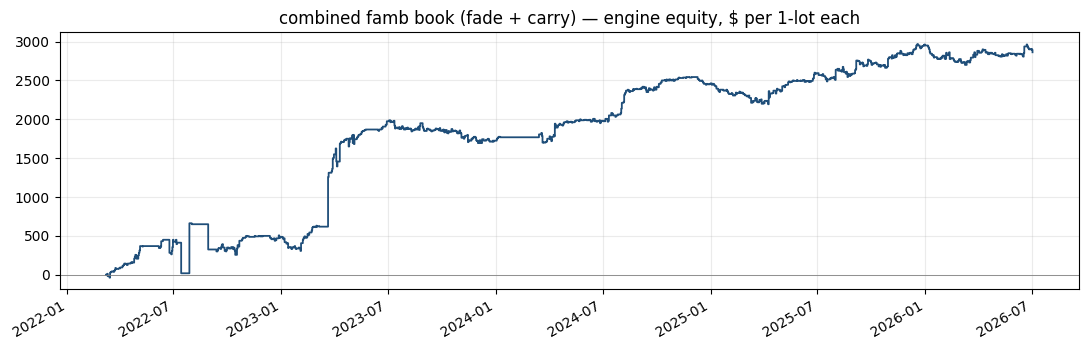

In [5]:
eq = pd.Series(bt.mtm_history).sort_index()
d = eq.diff().dropna()
sd = d.std(ddof=1)
print(f"combined daily MTM: Sharpe {d.mean() / sd * np.sqrt(252):+.2f}  "
      f"NW t {nw_tstat(d.to_numpy()):+.2f}  "
      f"maxDD ${(eq - eq.cummax()).min():,.0f}  "
      f"worst day ${d.min():,.0f}  skew {d.skew():+.2f}")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.step(eq.index, eq.values, where="post", lw=1.3, color="#1f4e79")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("combined famb book (fade + carry) — engine equity, "
             "$ per 1-lot each")
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Forward operation

This notebook IS the forward instrument: as new sessions land in the
quotes cache, rebuilding the panel/schedule extends the TimeGrid and the
same triggers keep firing — no parameter is free. Sleeve verdicts stand:
the fade is the mechanism-certified candidate discharging its selection
penalty forward; the carry remains uncertified income (NW t < 2) whose
job here is diversification (measured correlation −0.18).